# 11 -- Modeling (Classification: agle quarter At-Risk ya Healthy?)

**Project ka EKLAUTA sawal:** *Kya yeh company agle quarter `At-Risk` hogi ya `Healthy`?*

**Pichle steps ka recap:** `07` ne target banaya aur test companies lock kiye, `08` ne ratios treat kiye, `09` ne target ki nature samjhi, `10` ne features chune (`10_feature_selection_summary.json`).

**Yeh notebook kya karti hai:**
1. Model **sirf train companies** par train karti hai, aur **lock ki hui test companies** par ek baar evaluate karti hai.
2. Model ko **teen imtihanon** se guzarti hai, sirf "accuracy" se nahi:
   - **Majority baseline:** hamesha "At-Risk" bolo.
   - **Persistence baseline:** "jo abhi hai wahi agle quarter rahega" (`09` mein dikha tha yeh bohat mazboot hai).
   - **Status badalne wali rows:** jahan company sach mein Healthy se At-Risk (ya ulta) hoti hai, wahan model kaisa hai? Yehi asal kaam hai.
3. **Early-warning lift:** abhi Healthy companies mein se sabse zyada risky 10% ko chun-ne par kitni "girne wali" companies pakdi jati hain?
4. **Subgroups:** T+1 annual ya quarterly filing, revenue maujood ya missing, aur sector.

**Koi hard-coded result nahi:** har number code se nikalta hai.

## Working directory fix (zaroori)

In [1]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
                             confusion_matrix, brier_score_loss, roc_curve)
from sklearn.calibration import calibration_curve

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
MODEL_CHARTS_DIR = REPORTS_DIR / "figures" / "modeling_charts"
MODEL_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "10_final_dataset.parquet"
TARGET = "target_next_quarter_health"
SEED = 42

# ---- Features 10 ke faisle se (hard-coded nahi) ----
fs = json.load(open(REPORTS_DIR / "10_feature_selection_summary.json"))
FEATURES_NUM = fs["selected_ratio_growth_features"] + fs["selected_binary_context_features"]
SECTORS = fs["sector_categories"]
USE_SECTOR = fs["use_industry_sector"]

def build_feature_matrix(data):
    """Numeric + binary features, aur sector ke dummies (categories fix, taake columns hamesha wahi rahen)."""
    parts = [data[FEATURES_NUM].astype(float).reset_index(drop=True)]
    if USE_SECTOR:
        cat = pd.Categorical(data["industry_sector"], categories=SECTORS)
        parts.append(pd.get_dummies(cat, prefix="sector").astype(int).reset_index(drop=True))
    return pd.concat(parts, axis=1)

sns.set_style("whitegrid")
print(f"Features (10 ke faisle se): {FEATURES_NUM}")
print(f"Industry sector istemal: {USE_SECTOR} ({len(SECTORS)} categories)")

Features (10 ke faisle se): ['current_ratio', 'cash_ratio', 'debt_to_equity', 'debt_to_assets', 'operating_margin', 'roa', 'roe', 'asset_turnover', 'revenue_growth_qoq', 'netincome_growth_qoq', 'assets_growth_qoq', 'is_annual_filing', 'has_inventory']
Industry sector istemal: True (9 categories)


## Load 10 ka output + train/test (07 mein lock ki hui split)

In [3]:
df = pd.read_parquet(INPUT_PATH)
split = json.load(open(PROCESSED_DIR / "company_split.json"))
train_ciks, test_ciks = set(split["train_ciks"]), set(split["test_ciks"])

lab = df[df[TARGET].notna()].copy()
is_train = lab["cik"].astype(str).isin(train_ciks)
is_test = lab["cik"].astype(str).isin(test_ciks)
train, test = lab[is_train].copy(), lab[is_test].copy()

assert not (set(train["cik"]) & set(test["cik"])), "MASLA: company-overlap (leakage)!"
assert len(train) + len(test) == len(lab), "MASLA: kuch labelled rows na train mein na test mein"
assert len(train) == split["n_train_rows"] and len(test) == split["n_test_rows"], \
    "MASLA: split file aur dataset match nahi karte -- 07 se dobara chalayen"

X_train, X_test = build_feature_matrix(train), build_feature_matrix(test)
y_train = (train[TARGET] == "Healthy").astype(int).values     # 1 = Healthy, 0 = At-Risk
y_test = (test[TARGET] == "Healthy").astype(int).values

print(f"Train: {len(train)} rows, {train['cik'].nunique()} companies   |   Test: {len(test)} rows, {test['cik'].nunique()} companies")
print(f"Healthy share -> train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")
print(f"Company overlap: {len(set(train['cik']) & set(test['cik']))} (zero honi chahiye)")
print(f"Feature matrix: {X_train.shape[1]} columns")

Train: 27836 rows, 3922 companies   |   Test: 7050 rows, 981 companies
Healthy share -> train: 35.2%, test: 34.7%
Company overlap: 0 (zero honi chahiye)
Feature matrix: 22 columns


---
# PART 1 -- Baselines (model se pehle "aasan jawab" kitna achha hai?)

**Kahani:** Kisi student ke 88 number aaye. Agar paper itna aasan tha ke koi bhi bina padhe 87 le leta, to 88 kuch khaas nahi. Isliye pehle "bina padhe" wale jawab ka score dekhte hain.

- **Majority baseline:** hamesha wahi class bolo jo train mein zyada thi (`At-Risk`).
- **Persistence baseline:** agle quarter ka status = company ka **abhi** ka status. Jin rows mein current status compute nahi ho saka (`current_ratio`/`NetIncomeLoss` missing), wahan majority class bolte hain, taake dono model aur baseline **bilkul same rows** par compare hon.

Yeh dono baselines koi training nahi maangte.

In [4]:
majority_label = int(y_train.mean() >= 0.5)              # train ki majority (1 = Healthy)
pred_majority = np.full(len(y_test), majority_label)

cur = test["eval_current_health_state"]
pred_persist = np.where(cur.notna(), (cur == "Healthy").astype(int), majority_label)

def basic_metrics(y, pred, proba=None):
    out = {"accuracy": accuracy_score(y, pred), "balanced_accuracy": balanced_accuracy_score(y, pred),
           "f1_healthy": f1_score(y, pred, pos_label=1), "f1_atrisk": f1_score(y, pred, pos_label=0)}
    out["roc_auc"] = roc_auc_score(y, proba if proba is not None else pred)
    return out

m_majority = basic_metrics(y_test, pred_majority)
m_persist = basic_metrics(y_test, pred_persist)
print(f"Majority baseline (hamesha {'Healthy' if majority_label else 'At-Risk'}): accuracy = {m_majority['accuracy']:.4f}")
print(f"Persistence baseline ('jo abhi hai wahi rahega'):  accuracy = {m_persist['accuracy']:.4f}   ROC-AUC = {m_persist['roc_auc']:.4f}")
print(f"\nPersistence ke liye current status maujood: {cur.notna().mean():.1%} test rows")

Majority baseline (hamesha At-Risk): accuracy = 0.6532
Persistence baseline ('jo abhi hai wahi rahega'):  accuracy = 0.8600   ROC-AUC = 0.8449

Persistence ke liye current status maujood: 98.9% test rows


---
# PART 2 -- Model train karna (HistGradientBoosting, default parameters)

**Kahani:** Yeh model kai chhote decision trees ko ek ke baad ek jodta hai, har naya tree pichhle ki ghaltiyan theek karta hai. Do wajahon se yahan munasib hai:
1. **Missing values seedhi handle karta hai** (hamare kai ratios mein 15-60% tak values missing hain, aur missingness khud kabhi kabhi information hoti hai).
2. **Non-linear rishte** seekh leta hai (jaise "current_ratio 1 se upar hone par asar badalta hai").

Default parameters yahan jaan-boojh kar hain (tuning `12` mein, sirf train data ki cross-validation se). Test set par sirf ek baar evaluate hota hai.

In [5]:
clf = HistGradientBoostingClassifier(random_state=SEED)
clf.fit(X_train, y_train)

p_train = clf.predict_proba(X_train)[:, 1]
p_test = clf.predict_proba(X_test)[:, 1]
pred_train = (p_train >= 0.5).astype(int)
pred_test = (p_test >= 0.5).astype(int)

m_model = basic_metrics(y_test, pred_test, p_test)
train_acc, train_auc = accuracy_score(y_train, pred_train), roc_auc_score(y_train, p_train)

print(f"Train  accuracy = {train_acc:.4f}   ROC-AUC = {train_auc:.4f}")
print(f"Test   accuracy = {m_model['accuracy']:.4f}   ROC-AUC = {m_model['roc_auc']:.4f}")
print(f"Train-Test accuracy gap = {train_acc - m_model['accuracy']:+.4f}   (bara gap = overfitting ka ishara)")
print(f"Brier score (test) = {brier_score_loss(y_test, p_test):.4f}   (chhota behtar; 0.25 = 'hamesha 50%' bolne wala)")

Train  accuracy = 0.8992   ROC-AUC = 0.9583
Test   accuracy = 0.8762   ROC-AUC = 0.9367
Train-Test accuracy gap = +0.0230   (bara gap = overfitting ka ishara)
Brier score (test) = 0.0918   (chhota behtar; 0.25 = 'hamesha 50%' bolne wala)


In [6]:
comparison = pd.DataFrame({"Majority": m_majority, "Persistence": m_persist, "Model (HGB)": m_model}).T
comparison = comparison[["accuracy", "balanced_accuracy", "roc_auc", "f1_healthy", "f1_atrisk"]]
print(comparison.round(4).to_string())

gain_vs_majority = m_model["accuracy"] - m_majority["accuracy"]
gain_vs_persist = m_model["accuracy"] - m_persist["accuracy"]
print(f"\nModel - majority baseline    : {gain_vs_majority:+.4f} accuracy")
print(f"Model - persistence baseline : {gain_vs_persist:+.4f} accuracy")
if gain_vs_persist < 0.01:
    print("-> Accuracy mein model persistence se sirf thoda hi behtar hai. Iska matlab: model ki asal value 'hard label' mein nahi,")
    print("   risk ko RANK karne mein hai (agle parts dekhein).")

             accuracy  balanced_accuracy  roc_auc  f1_healthy  f1_atrisk
Majority       0.6532             0.5000   0.5000      0.0000     0.7902
Persistence    0.8600             0.8449   0.8449      0.7976     0.8930
Model (HGB)    0.8762             0.8653   0.9367      0.8230     0.9048

Model - majority baseline    : +0.2230 accuracy
Model - persistence baseline : +0.0162 accuracy


**Insight kaise padhein:** Persistence baseline se model ka accuracy-farq chhota ho to yeh **sach hai, ayb nahi**: agle quarter ka status zyada tar wahi rehta hai jo abhi hai, aur koi bhi model aisi
"sabse aasan kahani" ke muqable mein accuracy mein bohat aage nahi ja sakta. Isliye sirf accuracy se model ko judge karna galat hota. Neeche wale parts wahan dekhte hain jahan model sach mein kuch naya batata hai.

---
# PART 3 -- Asal imtihan: jahan status BADALTA hai

**Kahani:** Persistence baseline un rows mein hamesha ghalat hota hai jahan company Healthy se At-Risk (ya ulta) hoti hai, kyunki woh sirf purani kahani dohrata hai. Dekhte hain model in "badalne wali" rows mein kya karta hai.

Teen cheezein:
1. **Badalne wali rows par model ka accuracy** (persistence ke liye yeh 0% hai, by definition).
2. **Class-wise confusion matrix.**
3. **Early-warning lift:** abhi *Healthy* companies mein se model ke hisaab se sabse zyada risky 10% chunein. Un mein se kitni sach mein At-Risk hui, aur kul "girne wali" companies ka kitna hissa pakda gaya?

Status BADALNE wali rows: 956 (13.7% of rows jin ka current status maloom hai)
  Model ka accuracy BADALNE wali rows par : 21.7%   (persistence: 0.0%)
  Model ka accuracy NA badalne wali rows par: 98.2%

Confusion matrix (test):
                pred Healthy  pred At-Risk
actual Healthy          2029           416
actual At-Risk           457          4148


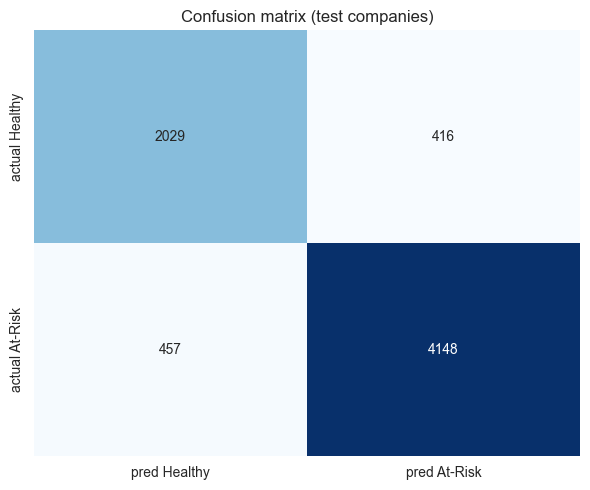

In [7]:
has_cur = cur.notna().values
changed = has_cur & ((cur == "Healthy").astype(int).values != y_test)

n_changed = int(changed.sum())
acc_on_changed = float((pred_test[changed] == y_test[changed]).mean())
acc_on_stayed = float((pred_test[has_cur & ~changed] == y_test[has_cur & ~changed]).mean())
print(f"Status BADALNE wali rows: {n_changed} ({n_changed / has_cur.sum():.1%} of rows jin ka current status maloom hai)")
print(f"  Model ka accuracy BADALNE wali rows par : {acc_on_changed:.1%}   (persistence: 0.0%)")
print(f"  Model ka accuracy NA badalne wali rows par: {acc_on_stayed:.1%}")

cm = confusion_matrix(y_test, pred_test, labels=[1, 0])
cm_df = pd.DataFrame(cm, index=["actual Healthy", "actual At-Risk"], columns=["pred Healthy", "pred At-Risk"])
print("\nConfusion matrix (test):")
print(cm_df.to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Confusion matrix (test companies)")
plt.tight_layout()
plt.savefig(MODEL_CHARTS_DIR / "01_confusion_matrix.png", dpi=120)
plt.show()

In [8]:
def lift_at_top(y_event, score, frac=0.10):
    """y_event = 1 jab 'ghatna' hui (jise pakadna hai). score = jitna zyada, utna zyada shak."""
    n = len(y_event)
    top_n = max(1, int(np.ceil(n * frac)))
    top = np.argsort(-score)[:top_n]
    base_rate = float(y_event.mean())
    top_rate = float(y_event[top].mean())
    return {"n_rows": n, "base_rate": base_rate, "top_decile_rate": top_rate,
            "lift": top_rate / base_rate if base_rate > 0 else float("nan"),
            "capture": float(y_event[top].sum() / y_event.sum()) if y_event.sum() > 0 else float("nan")}

# (a) Abhi Healthy -> kya At-Risk ho jayegi?  (girawat pakadna = early warning)
mask_h = (cur == "Healthy").values
y_fall = (y_test[mask_h] == 0).astype(int)
score_fall = 1 - p_test[mask_h]
lift_fall = lift_at_top(y_fall, score_fall)
auc_fall = roc_auc_score(y_fall, score_fall)

# (b) Abhi At-Risk -> kya Healthy ho jayegi?  (recovery pakadna)
mask_a = (cur == "At-Risk").values
y_recover = (y_test[mask_a] == 1).astype(int)
score_recover = p_test[mask_a]
lift_recover = lift_at_top(y_recover, score_recover)
auc_recover = roc_auc_score(y_recover, score_recover)

print("(a) Abhi HEALTHY companies (girawat pakadna):")
print(f"    rows={lift_fall['n_rows']}, asal mein At-Risk hone wali = {lift_fall['base_rate']:.1%}")
print(f"    Model ke sabse risky 10% mein At-Risk hone wali = {lift_fall['top_decile_rate']:.1%}  (lift = {lift_fall['lift']:.2f}x)")
print(f"    Kul girne wali companies ka {lift_fall['capture']:.1%} sirf 10% companies ko flag karke pakda gaya")
print(f"    AUC (Healthy ke andar rank karna) = {auc_fall:.4f}")
print("\n(b) Abhi AT-RISK companies (recovery pakadna):")
print(f"    rows={lift_recover['n_rows']}, asal mein Healthy hone wali = {lift_recover['base_rate']:.1%}")
print(f"    Model ke sabse umeedwar 10% mein Healthy hone wali = {lift_recover['top_decile_rate']:.1%}  (lift = {lift_recover['lift']:.2f}x)")
print(f"    AUC (At-Risk ke andar rank karna) = {auc_recover:.4f}")

(a) Abhi HEALTHY companies (girawat pakadna):
    rows=2432, asal mein At-Risk hone wali = 20.0%
    Model ke sabse risky 10% mein At-Risk hone wali = 64.3%  (lift = 3.21x)
    Kul girne wali companies ka 32.2% sirf 10% companies ko flag karke pakda gaya
    AUC (Healthy ke andar rank karna) = 0.8031

(b) Abhi AT-RISK companies (recovery pakadna):
    rows=4540, asal mein Healthy hone wali = 10.3%
    Model ke sabse umeedwar 10% mein Healthy hone wali = 43.4%  (lift = 4.20x)
    AUC (At-Risk ke andar rank karna) = 0.8459


**Insight kaise padhein:** **Lift** = "model ke chune hue top 10% mein ghatna kitni zyada hai, random 10% ke muqable mein". Lift 1 = model koi kaam ka nahi, lift 3 = random se 3 guna behtar.
**AUC** yahan "abhi Healthy" ke andar model ki risk-ranking ki quality hai (0.5 = andaza). Yeh number persistence baseline nahi de sakta (woh sab Healthy ko ek jaisa sample maanta hai).
Yeh dikhata hai ke model ki asal value **kisko pehle dekhna hai** batane mein hai, sirf "haan/na" mein nahi.

---
# PART 4 -- Probability kitni bharosemand hai? (Calibration)

**Kahani:** Agar model kisi company ke liye "70% Healthy" kahe, to aisi 100 companies mein se **lagbhag 70** sach mein Healthy honi chahiye. Agar nahi, to probability ko "percentage" ki tarah padhna galat hoga.

 model ne kaha (mean P Healthy)  asal mein Healthy   farq
                          0.009              0.006 -0.003
                          0.020              0.016 -0.004
                          0.030              0.023 -0.007
                          0.049              0.055  0.006
                          0.100              0.108  0.008
                          0.204              0.214  0.010
                          0.497              0.444 -0.053
                          0.779              0.756 -0.023
                          0.896              0.895 -0.001
                          0.953              0.952 -0.001

Average calibration gap (10 bins) = 0.012


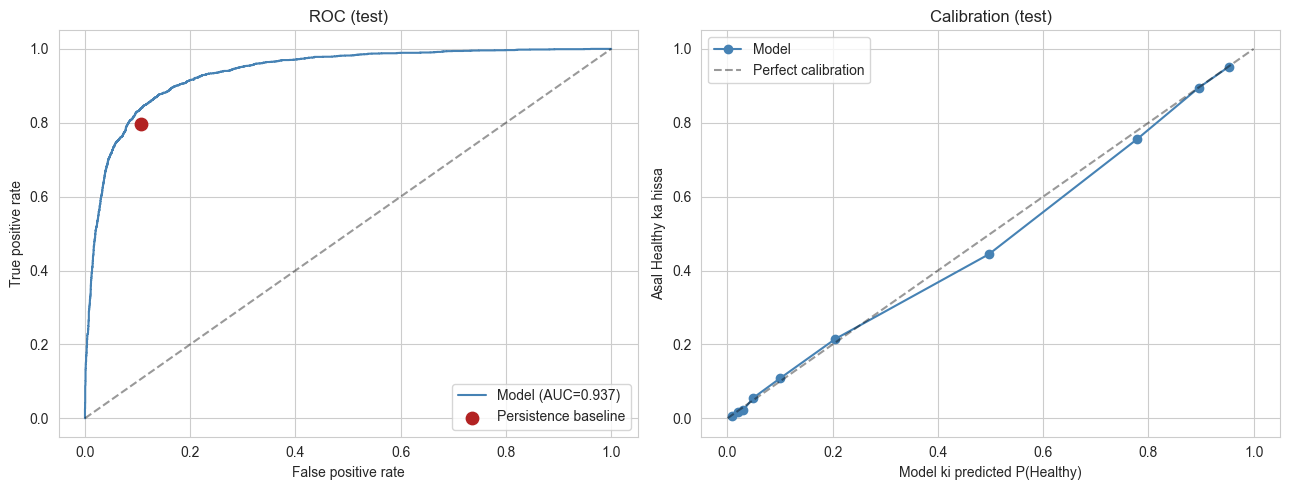

In [9]:
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
calib = pd.DataFrame({"model ne kaha (mean P Healthy)": mean_pred, "asal mein Healthy": frac_pos}).round(3)
calib["farq"] = (calib["asal mein Healthy"] - calib["model ne kaha (mean P Healthy)"]).round(3)
print(calib.to_string(index=False))
ece = float(np.abs(frac_pos - mean_pred).mean())
print(f"\nAverage calibration gap (10 bins) = {ece:.3f}")

fpr, tpr, _ = roc_curve(y_test, p_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"Model (AUC={m_model['roc_auc']:.3f})", color="steelblue")
p_fpr = ((pred_persist == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
p_tpr = ((pred_persist == 1) & (y_test == 1)).sum() / (y_test == 1).sum()
axes[0].scatter([p_fpr], [p_tpr], color="firebrick", s=80, zorder=5, label="Persistence baseline")
axes[0].plot([0, 1], [0, 1], "k--", alpha=.4)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate"); axes[0].set_title("ROC (test)"); axes[0].legend()
axes[1].plot(mean_pred, frac_pos, marker="o", color="steelblue", label="Model")
axes[1].plot([0, 1], [0, 1], "k--", alpha=.4, label="Perfect calibration")
axes[1].set_xlabel("Model ki predicted P(Healthy)"); axes[1].set_ylabel("Asal Healthy ka hissa"); axes[1].set_title("Calibration (test)"); axes[1].legend()
plt.tight_layout()
plt.savefig(MODEL_CHARTS_DIR / "02_roc_and_calibration.png", dpi=120)
plt.show()

---
# PART 5 -- Subgroups: model kahan kamzor hai?

**Kahani:** Ek average number kai farq chhupa sakta hai. Dataset ki nature se teen sawal zaroori hain:

1. **T+1 annual ya quarterly filing?** Annual T+1 par label "saal ka average quarter" hai, asli Q4 nahi (`03`/`07` ki documented limitation). Kya model dono par yaksaan hai?
2. **Revenue maujood ya missing?** `09` mein dikha tha ke revenue missing hona khud ek kamzor predictor hai. Agar model sirf isi shortcut par chal raha hota, to "revenue maujood" rows par kamzor hota.
3. **Sector:** kuch sectors (banks/REITs) ka `current_ratio` aksar hota hi nahi (`09`), wahan model kam bharosemand ho sakta hai.

In [10]:
def group_report(mask, name):
    n = int(mask.sum())
    if n < 50:
        return {"group": name, "n": n}
    y, p, pr = y_test[mask], p_test[mask], pred_test[mask]
    row = {"group": name, "n": n, "healthy_share": round(float(y.mean()), 3),
           "model_acc": round(float((pr == y).mean()), 4), "persist_acc": round(float((pred_persist[mask] == y).mean()), 4)}
    row["model_auc"] = round(float(roc_auc_score(y, p)), 4) if 0 < y.sum() < len(y) else float("nan")
    return row

rows = []
nxt = test["eval_next_is_annual_filing"]
rows.append(group_report((nxt == True).values, "T+1 = annual filing"))
rows.append(group_report((nxt == False).values, "T+1 = quarterly filing"))
rev_missing = test["Revenue_final"].isna().values
rows.append(group_report(~rev_missing, "Revenue MAUJOOD"))
rows.append(group_report(rev_missing, "Revenue MISSING"))
for s in SECTORS:
    rows.append(group_report((test["industry_sector"] == s).values, f"sector: {s}"))
subgroups = pd.DataFrame(rows)
print(subgroups.to_string(index=False))
subgroups.to_csv(REPORTS_DIR / "11_subgroup_performance.csv", index=False)

                      group    n  healthy_share  model_acc  persist_acc  model_auc
        T+1 = annual filing 1575          0.348     0.8914       0.8832     0.9577
     T+1 = quarterly filing 5475          0.346     0.8718       0.8533     0.9308
            Revenue MAUJOOD 5407          0.394     0.8585       0.8446     0.9264
            Revenue MISSING 1643          0.193     0.9343       0.9105     0.9545
        sector: Agriculture   72          0.306     0.8472       0.7778     0.8882
       sector: Construction   68          0.544     0.9412       0.8529     0.9372
 sector: Finance_RealEstate  669          0.327     0.8565       0.8132     0.9250
      sector: Manufacturing 3440          0.346     0.8837       0.8727     0.9428
             sector: Mining  298          0.302     0.8792       0.8557     0.9309
             sector: Retail  339          0.366     0.8938       0.8702     0.9537
           sector: Services 1501          0.332     0.8754       0.8674     0.9334
sect

**Insight kaise padhein:** `n` chhota ho (sau-do sau) to us subgroup ke numbers hil sakte hain, unhein "ishara" maanein, "saboot" nahi. Jahan `model_acc` persistence se kam ho ya `model_auc` bohat neeche ho, wahan model
kam bharosemand hai, aur README mein yehi limitation ke taur par likha jata hai.

---
# PART 6 -- Model kis cheez par tikka hai? (Permutation importance, test set par)

**Kahani:** Har feature ko baari baari shuffle kar ke dekhte hain AUC kitna girta hai. `industry_sector` ke saare dummy columns **ek saath ek unit** hain. Yeh sirf model ko **samajhne** ke liye hai;
features ka faisla `10` mein train data se ho chuka hai (test se nahi).

             feature  auc_drop_mean  auc_drop_std
       current_ratio         0.1877        0.0058
                 roa         0.1653        0.0057
    operating_margin         0.0241        0.0009
netincome_growth_qoq         0.0190        0.0009
     industry_sector         0.0042        0.0005
      debt_to_equity         0.0021        0.0003
  revenue_growth_qoq         0.0014        0.0002
      debt_to_assets         0.0013        0.0003
                 roe         0.0011        0.0002
      asset_turnover         0.0010        0.0001
          cash_ratio         0.0008        0.0002
   assets_growth_qoq         0.0007        0.0001
    is_annual_filing         0.0006        0.0001
       has_inventory         0.0001        0.0000


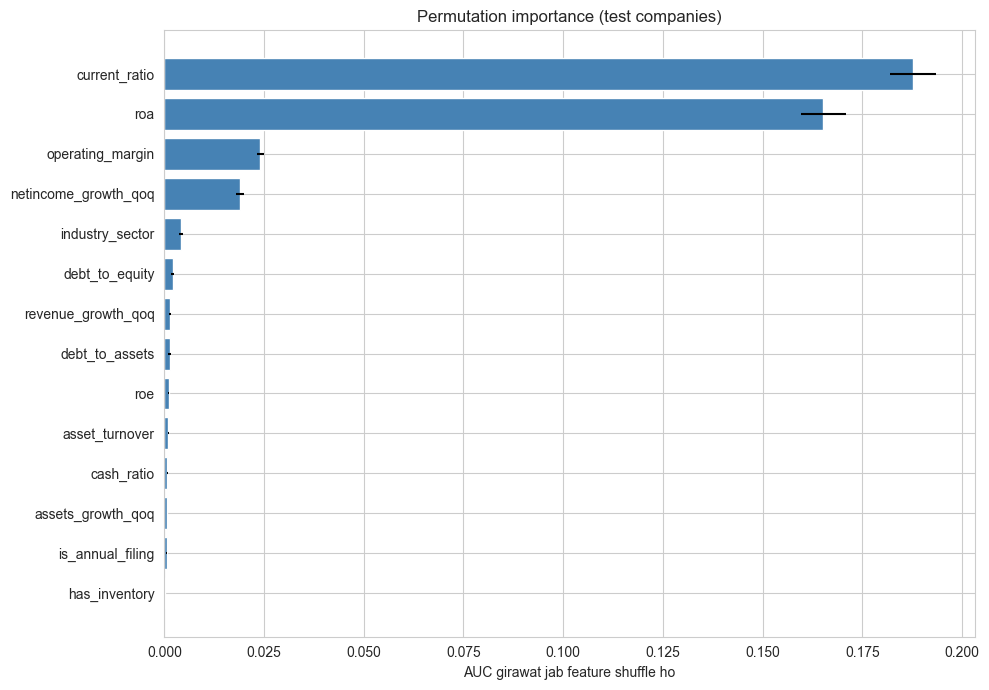

In [11]:
UNITS = {c: [c] for c in FEATURES_NUM}
if USE_SECTOR:
    UNITS["industry_sector"] = [c for c in X_test.columns if c.startswith("sector_")]

def permutation_importance_units(model, X, y, n_repeats=10):
    rng = np.random.default_rng(SEED)
    base = roc_auc_score(y, model.predict_proba(X)[:, 1])
    rows = []
    for u, cols in UNITS.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].values[rng.permutation(len(X))]
            drops.append(base - roc_auc_score(y, model.predict_proba(Xp)[:, 1]))
        rows.append({"feature": u, "auc_drop_mean": np.mean(drops), "auc_drop_std": np.std(drops)})
    return pd.DataFrame(rows).sort_values("auc_drop_mean", ascending=False).reset_index(drop=True)

importance = permutation_importance_units(clf, X_test, y_test)
print(importance.round(4).to_string(index=False))
importance.to_csv(REPORTS_DIR / "11_permutation_importance_test.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
s = importance.sort_values("auc_drop_mean")
ax.barh(s["feature"], s["auc_drop_mean"], xerr=s["auc_drop_std"], color="steelblue")
ax.set_xlabel("AUC girawat jab feature shuffle ho")
ax.set_title("Permutation importance (test companies)")
plt.tight_layout()
plt.savefig(MODEL_CHARTS_DIR / "03_permutation_importance.png", dpi=120)
plt.show()

**Insight kaise padhein:** Jo top features hain, aksar woh wahi hote hain jinse target ki definition banti hai (`current_ratio`, aur profit ki nishani jaise `roa`). Yeh ajeeb nahi: aaj ka liquidity aur profit level,
agle quarter ke status ka sabse bada ishara hai. Yehi wajah hai ke persistence itna mazboot baseline hai. Baaki features ka asar bohat chhota hai (upar table mein dekhein, `std` se mawazna karein: jo `auc_drop_mean` apne `std` se bara hai woh noise se upar hai).

---
# PART 7 -- Summary save + Sanity Checks

In [12]:
summary = {
    "generated_by": "11_modeling.ipynb",
    "target": TARGET,
    "features_numeric_binary": FEATURES_NUM,
    "sector_dummies_used": bool(USE_SECTOR),
    "n_train_rows": int(len(train)), "n_test_rows": int(len(test)),
    "n_train_companies": int(train["cik"].nunique()), "n_test_companies": int(test["cik"].nunique()),
    "healthy_share_train": round(float(y_train.mean()), 4), "healthy_share_test": round(float(y_test.mean()), 4),
    "model": "HistGradientBoostingClassifier(default params, random_state=42)",
    "train": {"accuracy": round(float(train_acc), 4), "roc_auc": round(float(train_auc), 4)},
    "test": {"majority": {k: round(float(v), 4) for k, v in m_majority.items()},
             "persistence": {k: round(float(v), 4) for k, v in m_persist.items()},
             "model": {k: round(float(v), 4) for k, v in m_model.items()},
             "brier": round(float(brier_score_loss(y_test, p_test)), 4),
             "calibration_gap": round(ece, 4)},
    "status_change": {"n_changed_rows": n_changed, "model_acc_on_changed": round(acc_on_changed, 4),
                      "model_acc_on_unchanged": round(acc_on_stayed, 4)},
    "early_warning_currently_healthy": {**{k: round(v, 4) if isinstance(v, float) else v for k, v in lift_fall.items()}, "auc": round(float(auc_fall), 4)},
    "recovery_currently_atrisk": {**{k: round(v, 4) if isinstance(v, float) else v for k, v in lift_recover.items()}, "auc": round(float(auc_recover), 4)},
}
with open(REPORTS_DIR / "11_modeling_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("[SAVED] reports/11_modeling_summary.json, 11_subgroup_performance.csv, 11_permutation_importance_test.csv")

# ---- Sanity checks ----
assert not (set(train["cik"]) & set(test["cik"])), "MASLA: leakage"
print("[OK] Train/test mein koi company common nahi.")

clf2 = HistGradientBoostingClassifier(random_state=SEED).fit(X_train, y_train)
assert np.allclose(clf2.predict_proba(X_test)[:, 1], p_test), "MASLA: model deterministic nahi"
print("[OK] Dobara train karne par wahi predictions (deterministic).")

assert list(clf.classes_) == [0, 1], "MASLA: class order badla"
print("[OK] classes_ = [0 (At-Risk), 1 (Healthy)], predict_proba ka column 1 = P(Healthy).")

assert len(list(MODEL_CHARTS_DIR.glob("*.png"))) == 3
print("[OK] 3 charts bane.")
print("\nAgla step: 12_model_validation_and_persistence.ipynb (CV, model comparison, tuning, model save)")

[SAVED] reports/11_modeling_summary.json, 11_subgroup_performance.csv, 11_permutation_importance_test.csv
[OK] Train/test mein koi company common nahi.
[OK] Dobara train karne par wahi predictions (deterministic).
[OK] classes_ = [0 (At-Risk), 1 (Healthy)], predict_proba ka column 1 = P(Healthy).
[OK] 3 charts bane.

Agla step: 12_model_validation_and_persistence.ipynb (CV, model comparison, tuning, model save)
